##  Generating all-sky source catalogs with ROSALIA

In [8]:
import rosalia as rs 
import astropy.units as u

This notebook demonstrates the get_hybrid_catalog tool, a ROSALIA tool that automatically queries Gaia / 2MASS / WISE / Hipparcos and JPL / Horizons to retrieve a catalog of sources all-sky. 

Retrieving all-source in all-sky directions is not practical for obvious reasons, but at longer angular distances from our pointing we can bin together objectds that are closer together. This method allows for precise calculations on stray-light while taking into account all the received flux. 

Under regular conditions, the ROSALIA user does not interact directly with get_hybrid_catalog, but here is a demonstration of how to do it to add more flexibility. 

See Borlaff et al. 2022, Euclid Collaboration for more information. 

https://ui.adsabs.harvard.edu/abs/2022A&A...657A..92E

In [13]:
ra = 200 # degrees
dec = +30 # degrees
radius = 2 # degrees - Remember! Increasing this value too much will request WAY too many stars for the Gaia query. 1 - 2 degrees of full-resolution might be enough. 
lambda_ref = 1.2000*u.um # 1.2 micron. 
MJD = 61192.00 # Modified Julian Date 
g_mag_max = 15 # Maximum magnitude in the Gaia G-band of the stars to be considered. Dimmer sources than this are not retrieved. Default: 15 G-band magnitude.  
observer="Roman"

catalog = rs.psf.get_hybrid_catalog(ra=ra, dec=dec, radius=radius, lambda_ref=lambda_ref, 
                                    MJD=MJD, observer=observer, g_mag_max=g_mag_max, 
                                    verbose=False, query_filename="default_query.dat")

INFO: Retrieving tables... [astroquery.utils.tap.core]
INFO: Parsing tables... [astroquery.utils.tap.core]
INFO: Done. [astroquery.utils.tap.core]

INFO: Query finished. [astroquery.utils.tap.core]


[DEMO WARNING:] Naked eye stars do not have photometry besides g band


(202.0, 198.0)

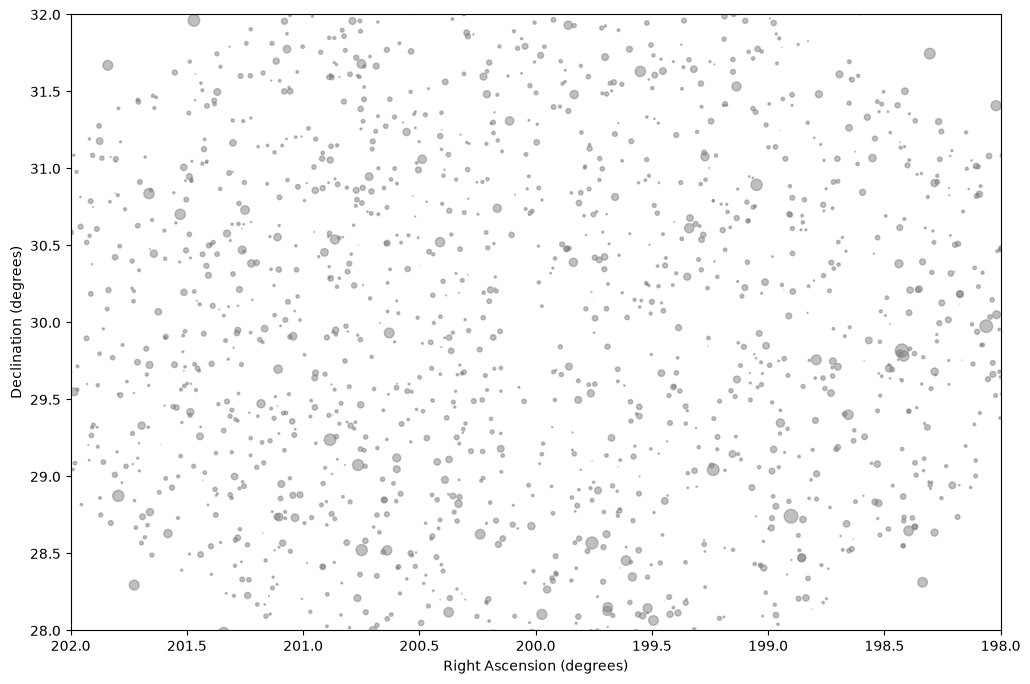

In [52]:
import matplotlib.pyplot as plt
import numpy as np 

fig, ax = plt.subplots(figsize=(12,8))
ax.scatter(catalog["ra"], catalog["dec"], s=1000/catalog["mag_lambda"]-70, color="grey",  alpha=0.5)
ax.set_xlabel("Right Ascension (degrees)")
ax.set_ylabel("Declination (degrees)")
ax.set_ylim(28,32)
ax.set_xlim(202,198)

In [34]:
catalog

,healpix_lvl,source_id,ra,dec,phot_g_mean_mag_AB,phot_bp_mean_mag_AB,phot_rp_mean_mag_AB,phot_j_mean_mag_AB,phot_h_mean_mag_AB,phot_ks_mean_mag_AB,...,j_error,h,h_error,ks,ks_error,g,bp,rp,mag_lambda,cat_id
0,NaN,Sun,68.840710,21.924190,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-27.038632,1
0,NaN,Earth,95.383400,15.454470,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-9.365632,2
0,NaN,Moon,100.867660,11.376880,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.654632,3
0,NaN,Venus,106.443510,24.425690,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.284632,4
0,NaN,Jupiter,115.606560,21.753410,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.223632,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1140,41573.0,1462754264883942272,199.267976,30.241588,15.038959,15.081474,15.037952,15.337779,15.610250,15.986174,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.314564,199059
2199,41583.0,1463092227270545280,198.256812,31.022565,15.083209,15.112001,15.072315,15.359778,15.661251,16.059174,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.337521,199060
561,41215.0,1450152865196634112,202.567839,29.793724,14.947420,14.908985,15.068472,15.404778,15.921249,16.300175,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.378739,199061
772,41595.0,1463524472779250304,199.055393,31.948196,14.718197,14.625235,14.956506,15.509778,15.975250,16.485174,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.466939,199062
